In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as ms
%matplotlib inline
plt.rc('font', size = 11)
sns.set_style('darkgrid')

In [4]:
df = pd.read_csv('traffic_violaions.csv')
df.head()

,stop_date,stop_time,country_name,driver_gender,driver_age_raw,driver_age,driver_race,violation_raw,violation,search_conducted,search_type,stop_outcome,is_arrested,stop_duration,drugs_related_stop
0,1/2/2005,1:55,NaN,M,1985.0,20.0,White,Speeding,Speeding,False,NaN,Citation,False,0-15 Min,False
1,1/18/2005,8:15,NaN,M,1965.0,40.0,White,Speeding,Speeding,False,NaN,Citation,False,0-15 Min,False
2,1/23/2005,23:15,NaN,M,1972.0,33.0,White,Speeding,Speeding,False,NaN,Citation,False,0-15 Min,False
3,2/20/2005,17:15,NaN,M,1986.0,19.0,White,Call for Service,Other,False,NaN,Arrest Driver,True,16-30 Min,False
4,3/14/2005,10:00,NaN,F,1984.0,21.0,White,Speeding,Speeding,False,NaN,Citation,False,0-15 Min,False


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52966 entries, 0 to 52965
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   stop_date           52966 non-null  object 
 1   stop_time           52965 non-null  object 
 2   country_name        0 non-null      float64
 3   driver_gender       49580 non-null  object 
 4   driver_age_raw      49588 non-null  float64
 5   driver_age          49346 non-null  float64
 6   driver_race         49581 non-null  object 
 7   violation_raw       49581 non-null  object 
 8   violation           49581 non-null  object 
 9   search_conducted    52965 non-null  object 
 10  search_type         2085 non-null   object 
 11  stop_outcome        49581 non-null  object 
 12  is_arrested         49581 non-null  object 
 13  stop_duration       49581 non-null  object 
 14  drugs_related_stop  52965 non-null  object 
dtypes: float64(3), object(12)
memory usage: 6.1+ MB


In [6]:
ms.matrix(df);

In [7]:
df1 = df.copy(deep=True)
df1.drop(columns = ['country_name','search_type','driver_age_raw'], inplace=True)
df1.dropna(subset = ['driver_gender'], inplace = True)

In [8]:
df.isna().sum()

stop_date                 0
stop_time                 1
country_name          52966
driver_gender          3386
driver_age_raw         3378
driver_age             3620
driver_race            3385
violation_raw          3385
violation              3385
search_conducted          1
search_type           50881
stop_outcome           3385
is_arrested            3385
stop_duration          3385
drugs_related_stop        1
dtype: int64

In [9]:
df2 = df1.copy(deep=True)
df2['driver_age'] = df2['driver_age'].fillna(df.groupby('driver_gender')['driver_age'].transform('median'))
ms.matrix(df);

In [13]:
import pandas as pd

# Sample data (replace this with your actual dataset)
data = pd.DataFrame({
    'stop_date': ['2021-01-01', '2021-01-02', '2022-01-01'],
    'stop_time': ['12:00', '13:00', '14:00'],
    'search_conducted': [True, False, True],
    'violations': [1, 0, 3]
})

# Ensure 'stop_date' and 'stop_time' are in datetime format
data['stop_date'] = pd.to_datetime(data['stop_date'])
data['stop_time'] = pd.to_datetime(data['stop_time'], format='%H:%M', errors='coerce')

# Extract the year from 'stop_date'
data['stop_Year'] = data['stop_date'].dt.year

# Group by year and sum numeric columns
yearly_data = data.groupby('stop_Year').sum(numeric_only=True)

# Reset index for a clean DataFrame
yearly_data.reset_index(inplace=True)

# Output the yearly data
print(yearly_data)


   stop_Year  search_conducted  violations
0       2021                 1           1
1       2022                 1           3


In [14]:
data.head()

,stop_date,stop_time,search_conducted,violations,stop_Year
0,2021-01-01,1900-01-01 12:00:00,True,1,2021
1,2021-01-02,1900-01-01 13:00:00,False,0,2021
2,2022-01-01,1900-01-01 14:00:00,True,3,2022


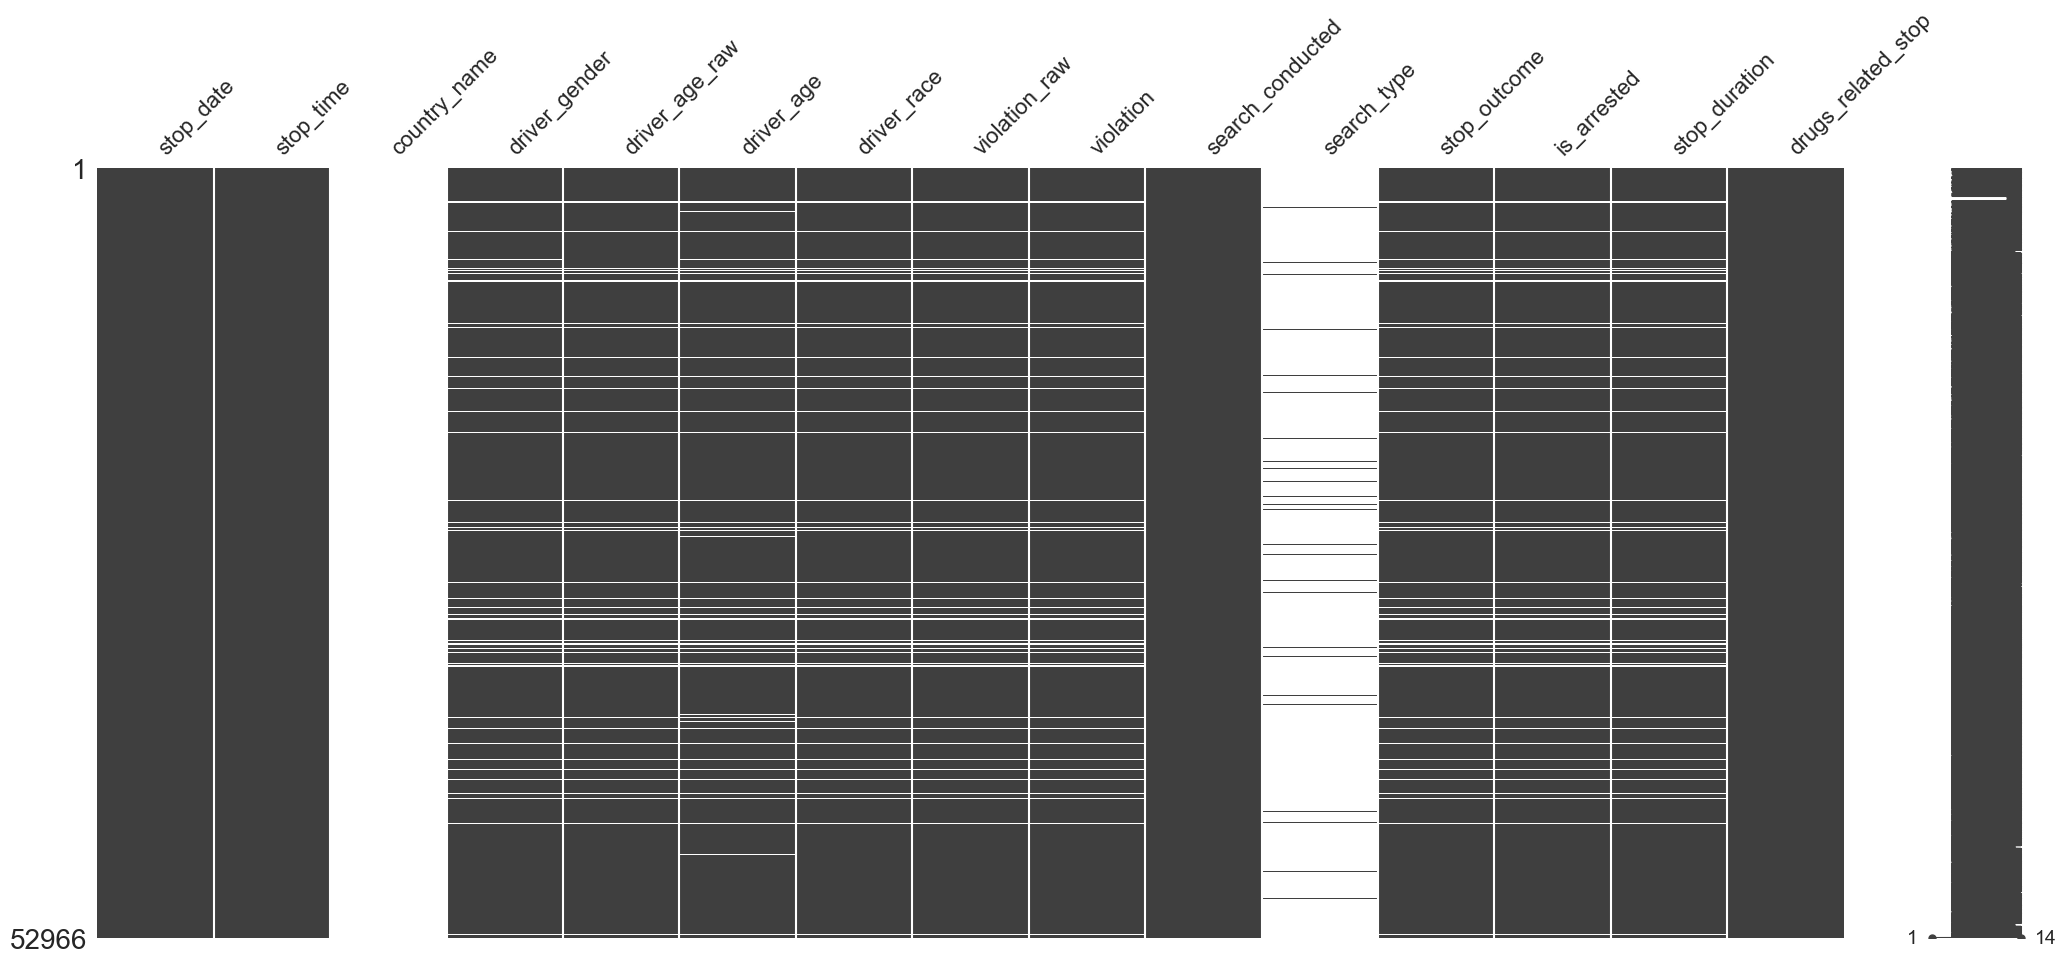

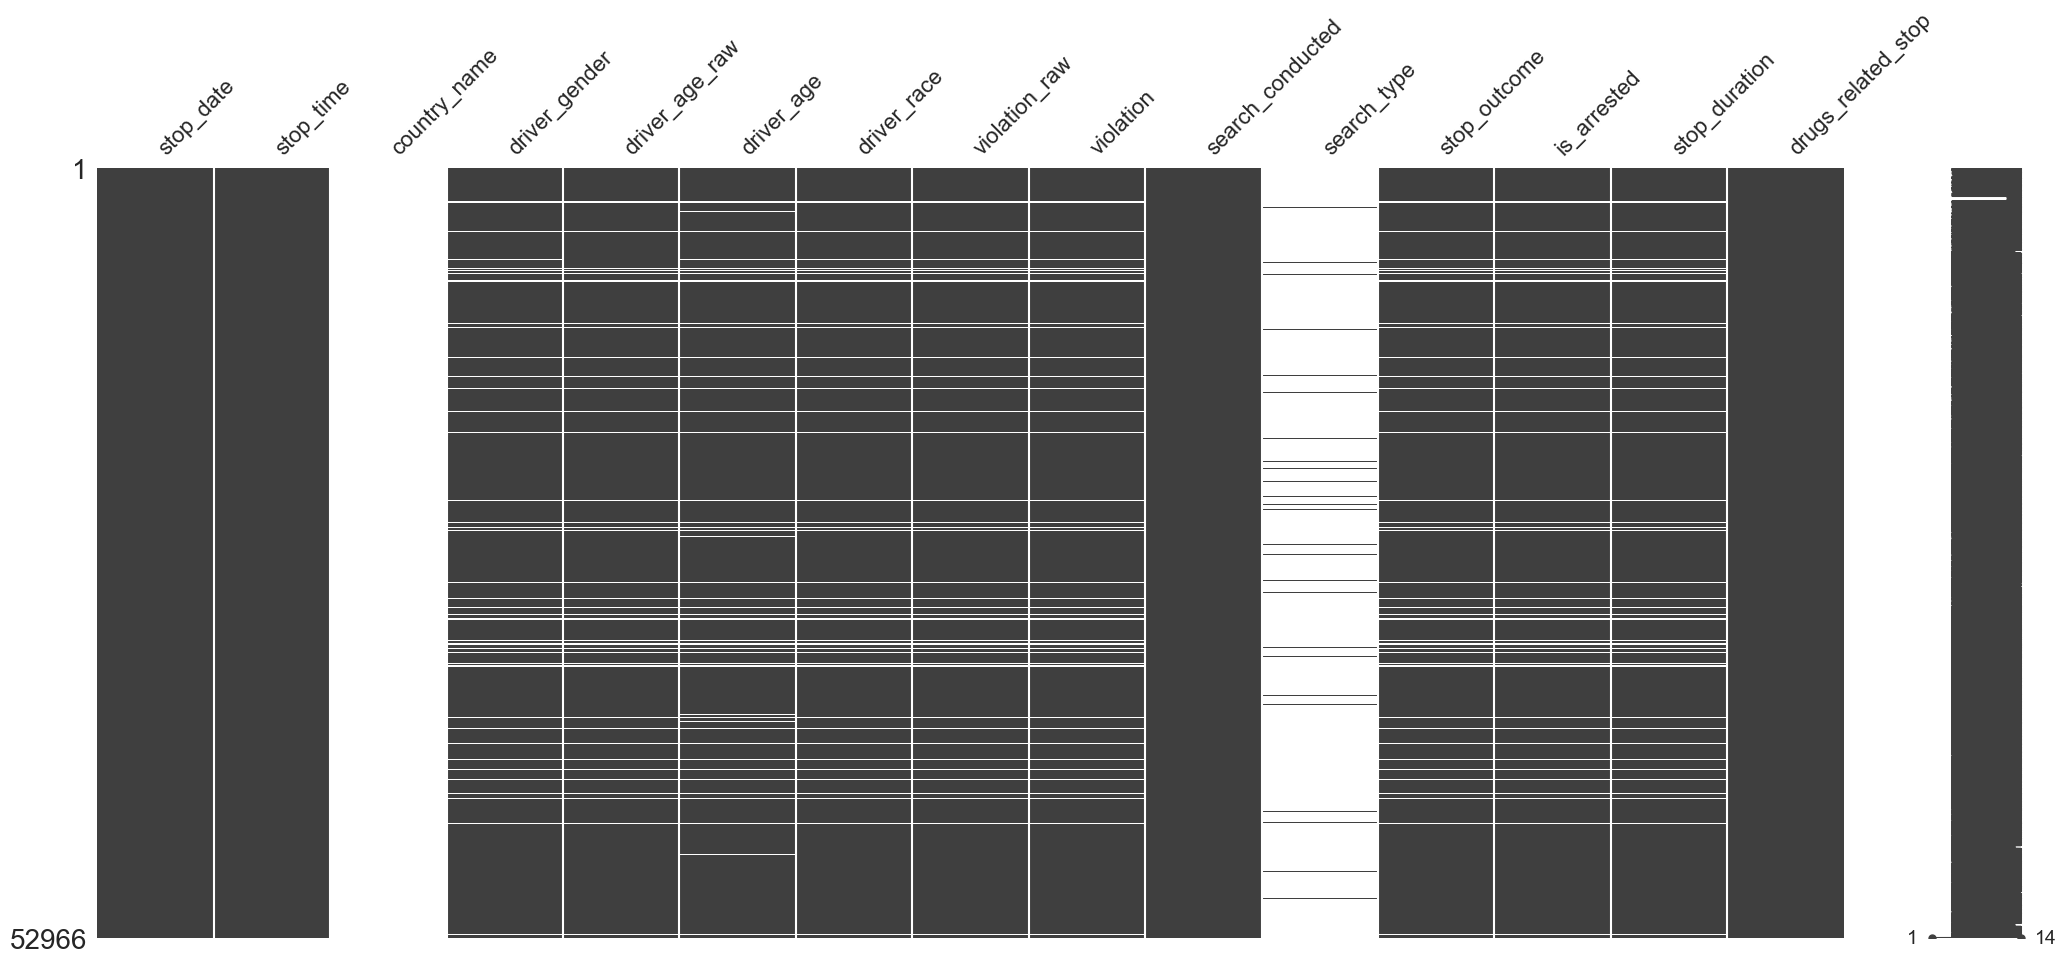

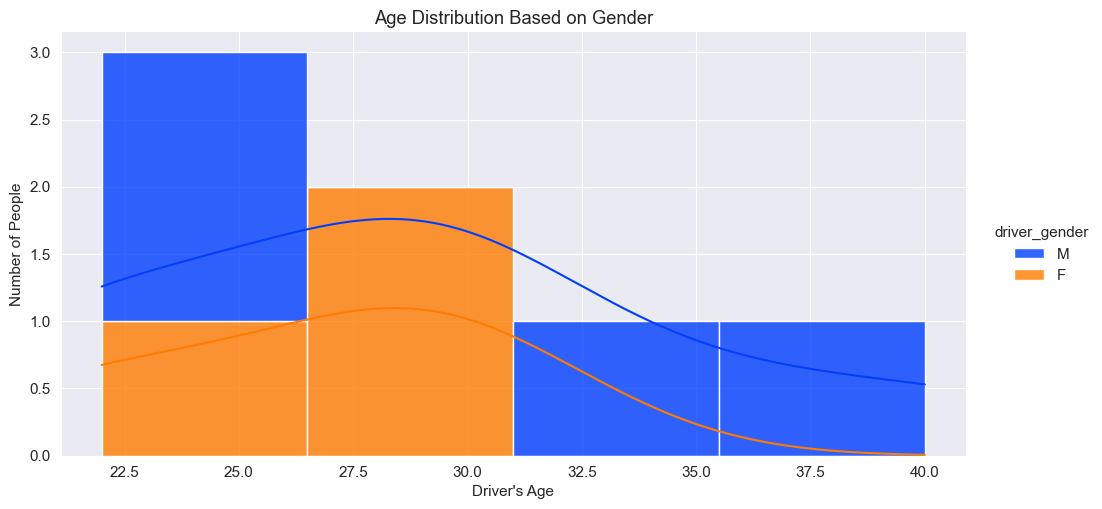

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sample data (ensure 'driver_age' and 'driver_gender' exist in your dataset)
data = pd.DataFrame({
    'driver_age': [25, 30, 22, 40, 35, 28, 23],
    'driver_gender': ['M', 'F', 'F', 'M', 'M', 'F', 'M']
})

# Create the distribution plot
sns.displot(
    x='driver_age',
    hue='driver_gender',
    kde=True,
    data=data,
    multiple='stack',
    alpha=0.8,
    palette="bright",
    height=5,
    aspect=2
)
plt.title('Age Distribution Based on Gender')
plt.xlabel("Driver's Age")
plt.ylabel("Number of People")
plt.show()


C:\Users\Ashish Mishra\AppData\Local\Temp\ipykernel_10372\1919341854.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=data['violation'], data=data, order=data['violation'].value_counts().index, palette="bright")


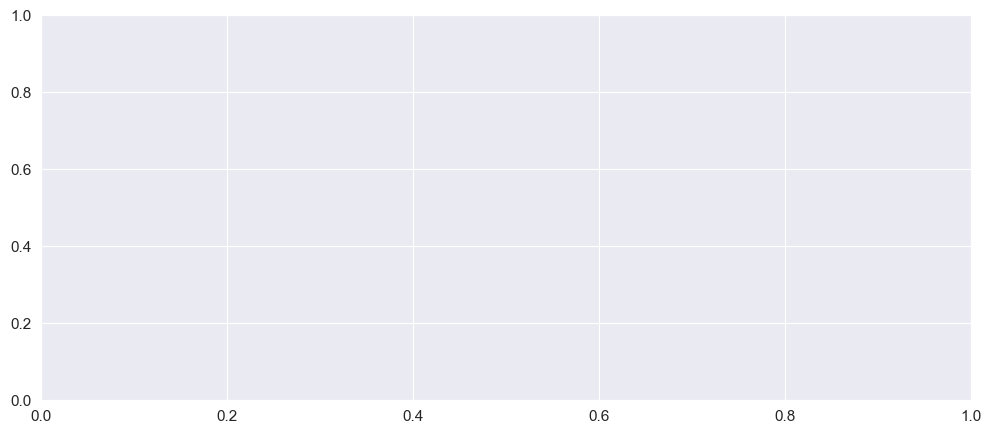

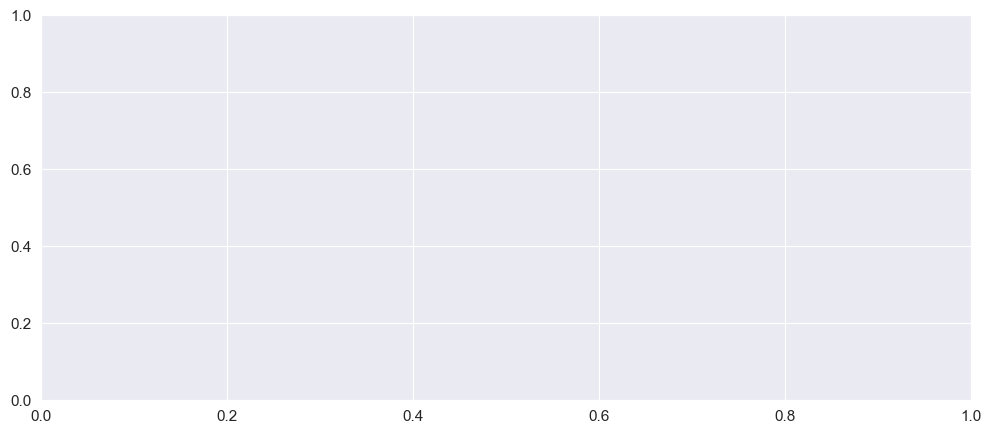

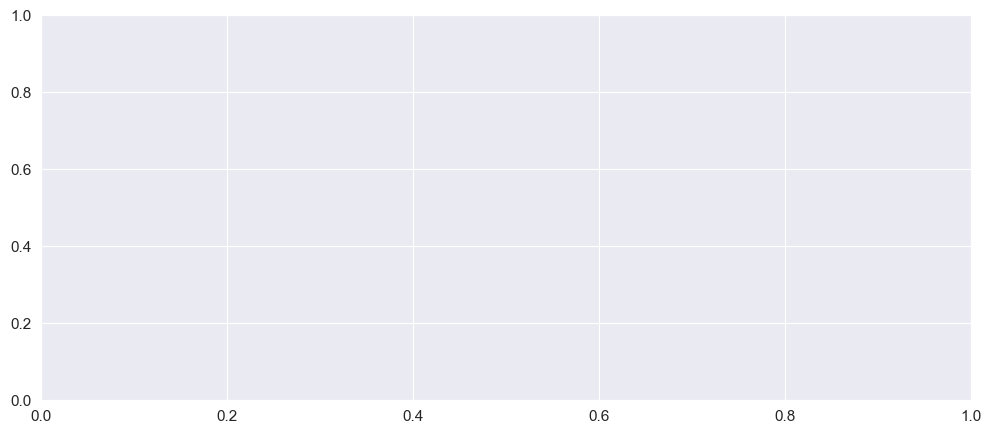

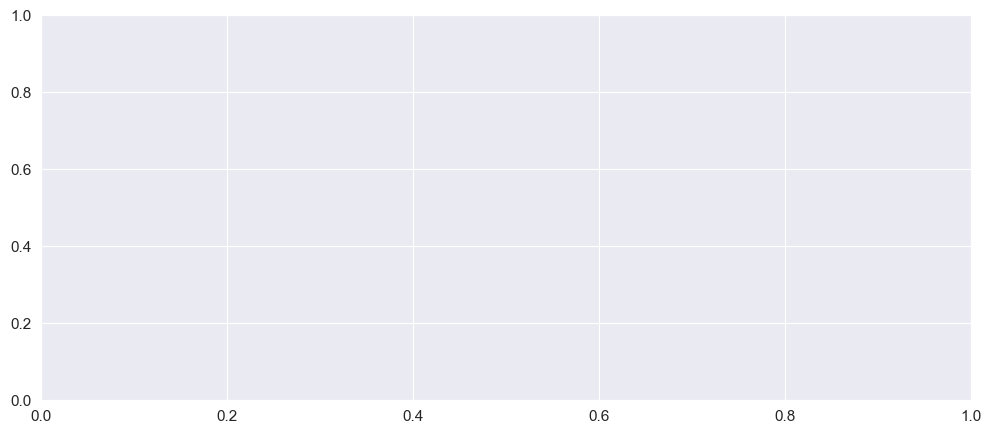

<Figure size 1200x500 with 0 Axes>

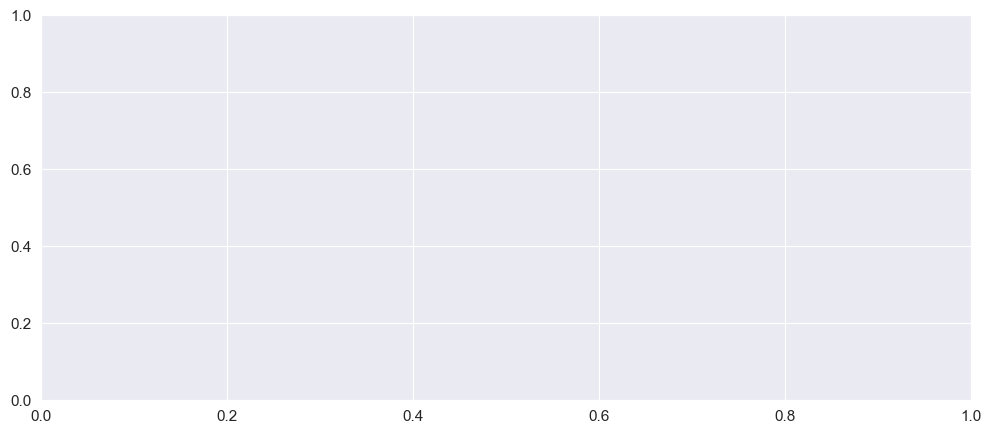

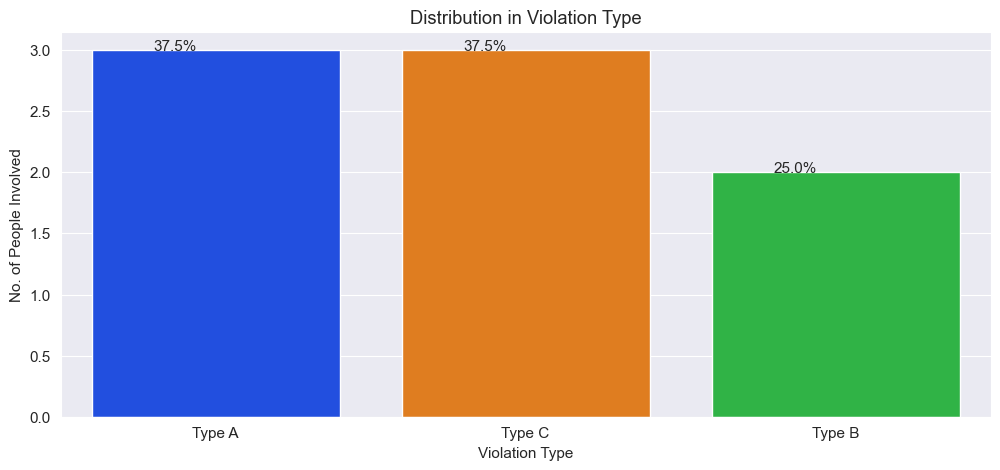

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Example DataFrame structure
import pandas as pd
data = pd.DataFrame({
    'violation': ['Type A', 'Type B', 'Type A', 'Type C', 'Type A', 'Type B', 'Type C', 'Type C']
})

fig, ax = plt.subplots(figsize=(12, 5))
ax = sns.countplot(x=data['violation'], data=data, order=data['violation'].value_counts().index, palette="bright")
for i in ax.patches:
    percentage = '{:.1f}%'.format(100 * i.get_height() / len(data['violation']))
    x = i.get_x() + i.get_width() - 0.6
    y = i.get_height()
    ax.annotate(percentage, (x, y))
plt.title("Distribution in Violation Type")
plt.xlabel("Violation Type")
plt.ylabel("No. of People Involved")
plt.show()


<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

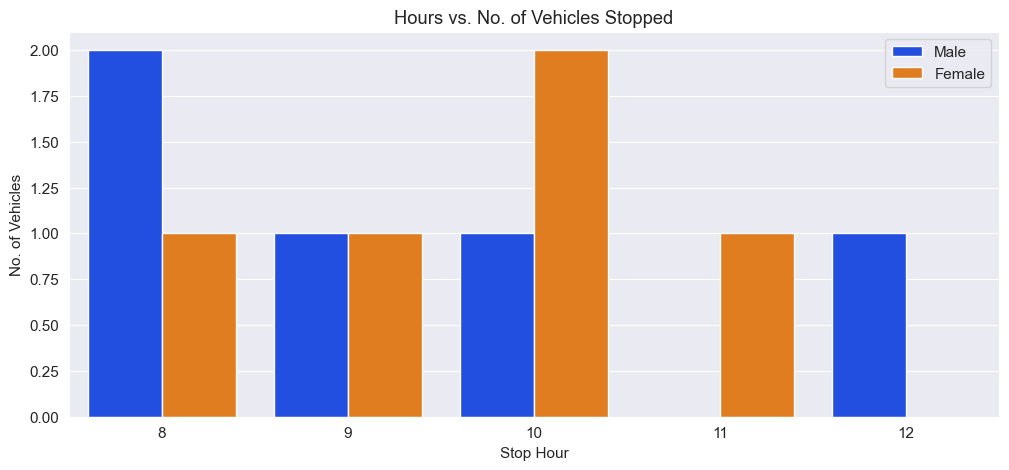

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Example DataFrame
data = pd.DataFrame({
    'stop_hour': [8, 9, 10, 10, 8, 9, 11, 12, 8, 10],
    'driver_gender': ['Male', 'Female', 'Male', 'Female', 'Male', 'Male', 'Female', 'Male', 'Female', 'Female']
})

# Plot
plt.figure(figsize=(12, 5))
sns.countplot(x='stop_hour', data=data, hue='driver_gender', palette="bright")
plt.title('Hours vs. No. of Vehicles Stopped')
plt.legend(['Male', 'Female'])
plt.xlabel("Stop Hour")
plt.ylabel("No. of Vehicles")
plt.show()


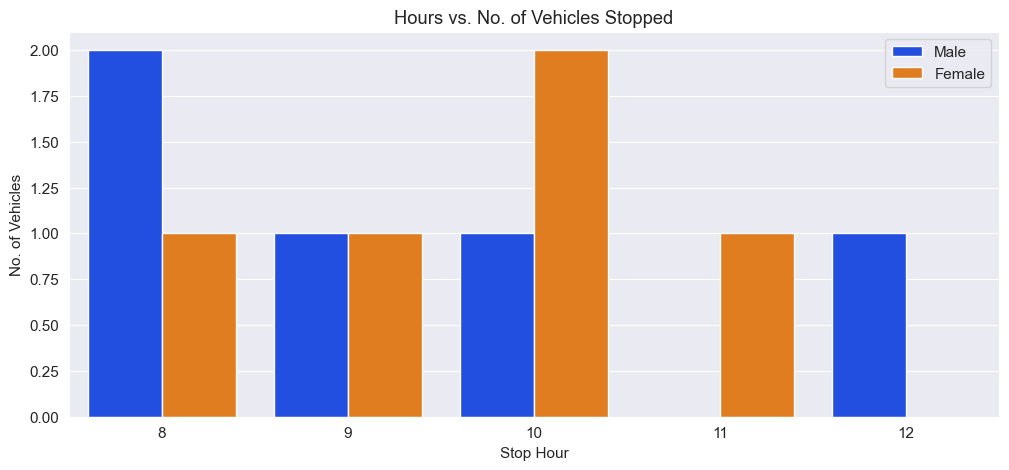

In [29]:
plt.figure(figsize=(12, 5))
sns.countplot(x=data['stop_hour'], data=data, hue='driver_gender', palette="bright")
plt.title('Hours vs. No. of Vehicles Stopped')
plt.legend(['Male', 'Female'])
plt.xlabel("Stop Hour")
plt.ylabel("No. of Vehicles")
plt.show()


In [30]:
plt.figure(figsize = (12,5))
sns.countplot(x = data.stop_hour,data = data,hue = 'driver_gender', palette = "bright")
plt.title('Hours vs. No. of Vehicles Stopped')
plt.legend(['Male','Female'])
plt.xlabel("Stop Hour")
plt.ylabel("No. of Vehicles");

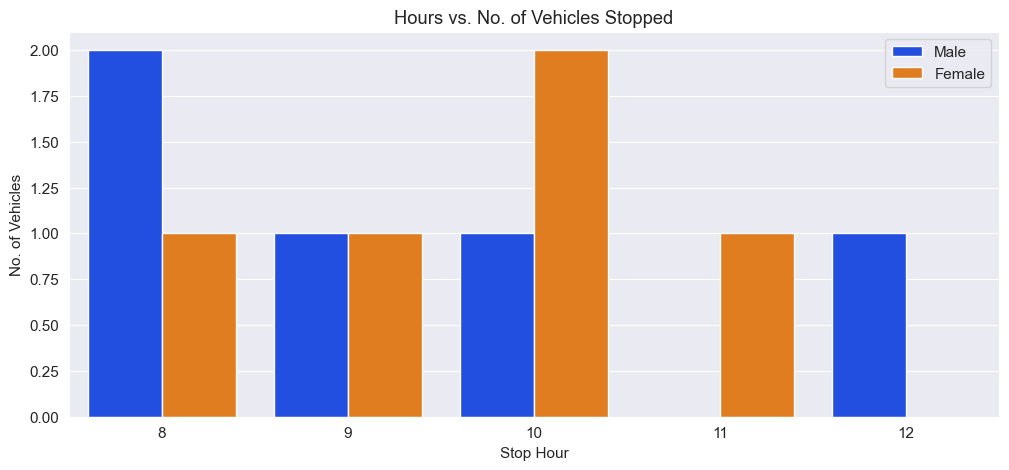

<Figure size 1200x500 with 0 Axes>

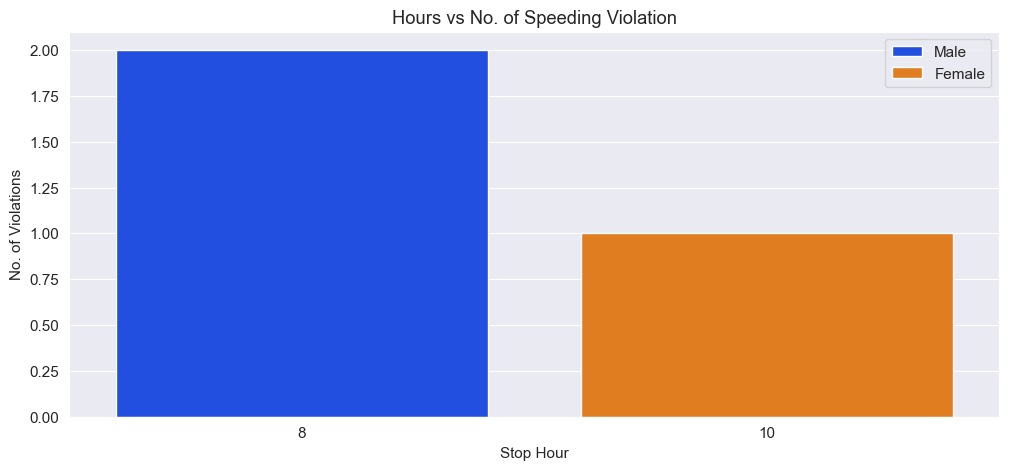

In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Example dataset
data = pd.DataFrame({
    'violation': ['Moving violation', 'Parking violation', 'Moving violation', 'Moving violation'],
    'stop_hour': [8, 9, 10, 8],
    'driver_gender': ['Male', 'Female', 'Female', 'Male']
})

# Filter data for "Moving violation"
filtered_data = data[data['violation'] == 'Moving violation']

# Plot
plt.figure(figsize=(12, 5))
sns.countplot(x='stop_hour', data=filtered_data, hue='driver_gender', palette="bright")
plt.title('Hours vs No. of Speeding Violation')
plt.legend(['Male', 'Female'])
plt.xlabel("Stop Hour")
plt.ylabel("No. of Violations")
plt.show()


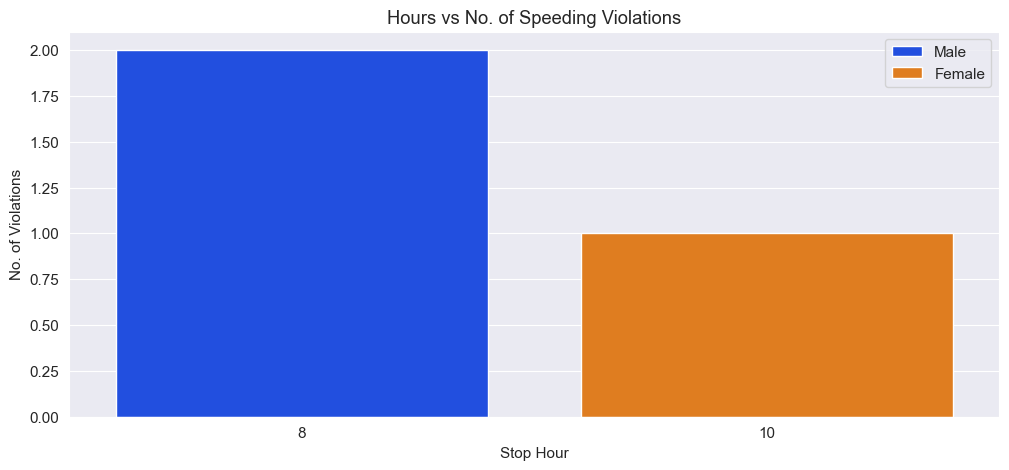

In [33]:
plt.figure(figsize=(12, 5))
sns.countplot(
    x=data[data['violation'] == 'Moving violation']['stop_hour'],
    data=data[data['violation'] == 'Moving violation'],
    hue='driver_gender',
    palette="bright"
)
plt.title('Hours vs No. of Speeding Violations')
plt.legend(['Male', 'Female'])
plt.xlabel("Stop Hour")
plt.ylabel("No. of Violations")
plt.show()


C:\Users\Ashish Mishra\AppData\Local\Temp\ipykernel_10372\766048057.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


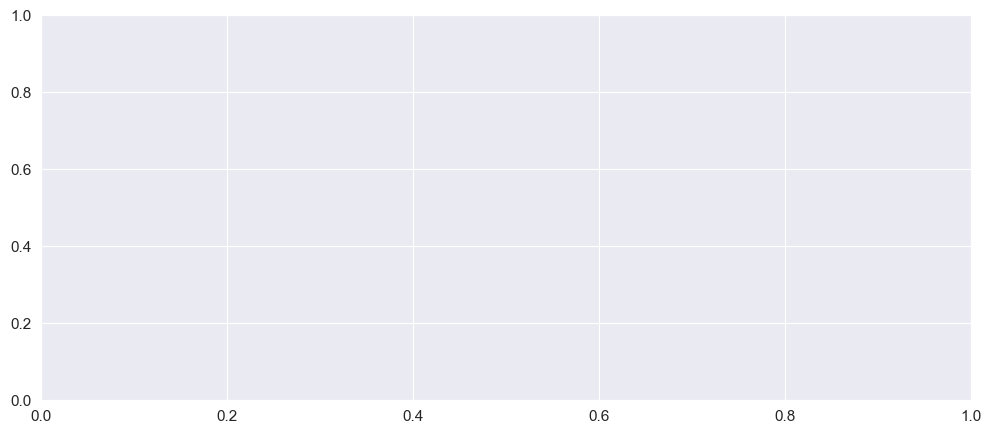

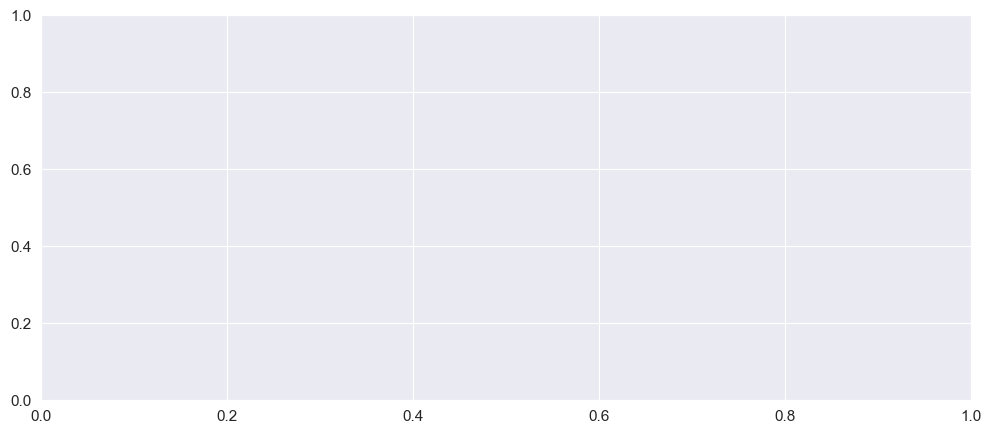

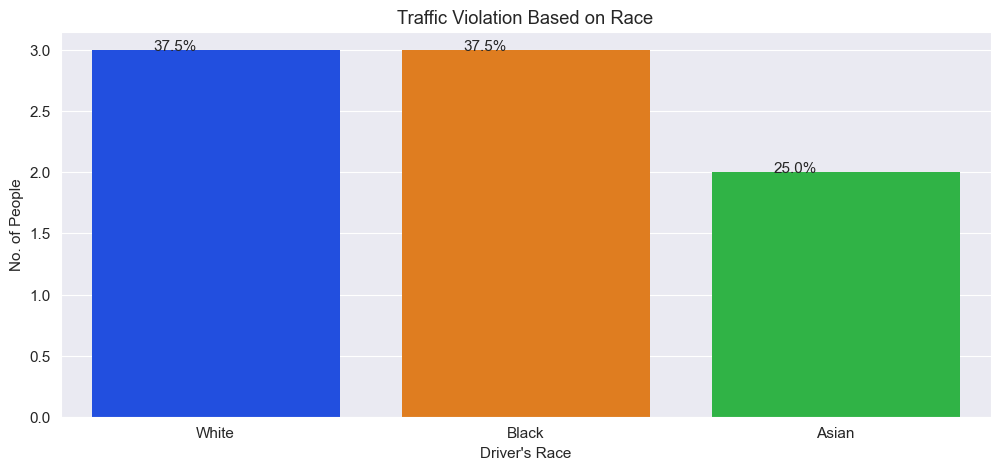

In [36]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Example DataFrame
data = pd.DataFrame({
    'driver_race': ['White', 'Black', 'Asian', 'White', 'Black', 'Asian', 'White', 'Black'],
    'violation': ['Speeding', 'Parking', 'Moving', 'Speeding', 'Speeding', 'Moving', 'Parking', 'Moving']
})

fig, ax = plt.subplots(figsize=(12, 5))
ax = sns.countplot(
    x=data['driver_race'], 
    data=data, 
    order=data['driver_race'].value_counts().index,
    linewidth=0, 
    palette="bright"
)
for i in ax.patches:
    percentage = '{:.1f}%'.format(100 * i.get_height() / len(data['driver_race']))
    x = i.get_x() + i.get_width() - 0.6
    y = i.get_height()
    ax.annotate(percentage, (x, y))
plt.title('Traffic Violation Based on Race')
plt.xlabel("Driver's Race")
plt.ylabel("No. of People")
plt.show()


C:\Users\Ashish Mishra\AppData\Local\Temp\ipykernel_10372\327004951.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


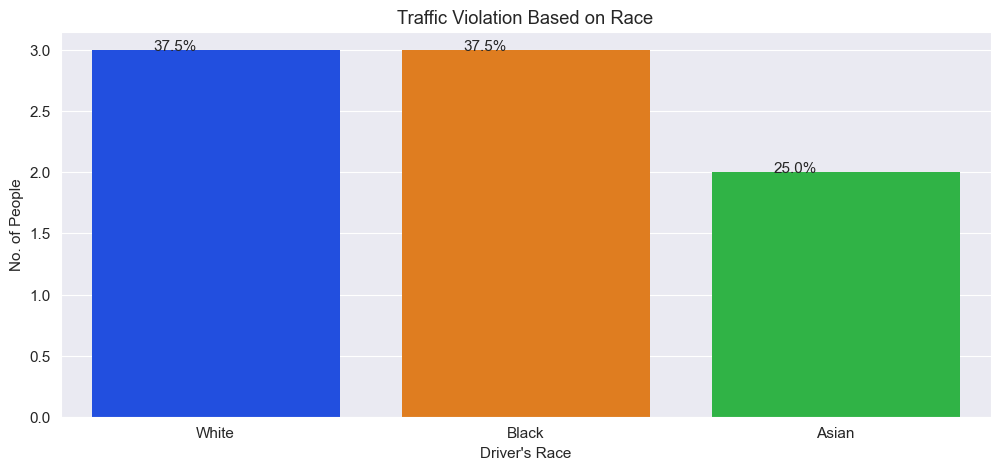

In [37]:
fig, ax = plt.subplots(figsize=(12, 5))
ax = sns.countplot(
    x=data['driver_race'], 
    data=data, 
    order=data['driver_race'].value_counts().index,
    linewidth=0, 
    palette="bright"
)
for i in ax.patches:
    percentage = '{:.1f}%'.format(100 * i.get_height() / len(data['driver_race']))
    x = i.get_x() + i.get_width() - 0.6
    y = i.get_height()
    ax.annotate(percentage, (x, y))
plt.title('Traffic Violation Based on Race')
plt.xlabel("Driver's Race")
plt.ylabel("No. of People")
plt.show()


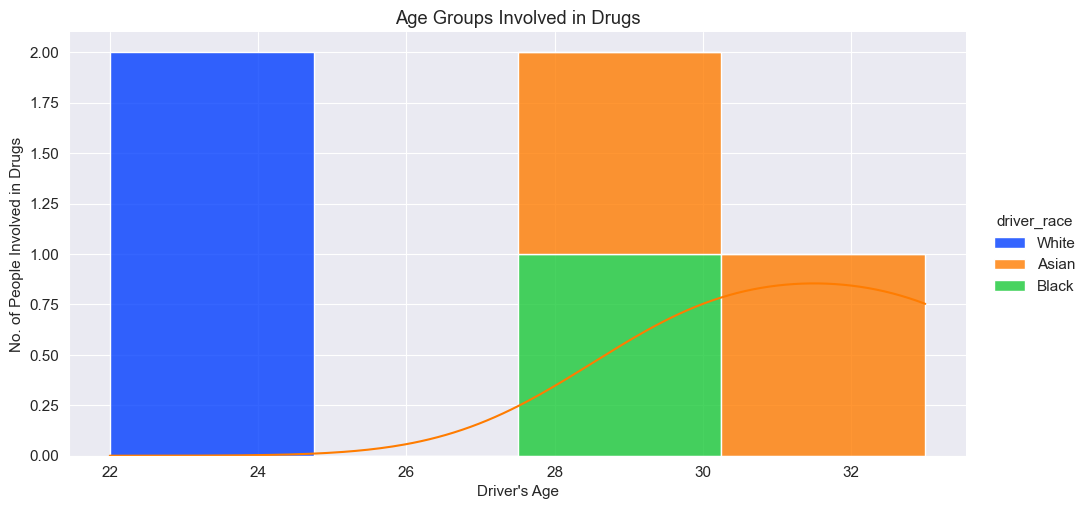

In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Example DataFrame
data = pd.DataFrame({
    'driver_age': [22, 25, 30, 22, 29, 33, 28, 21],
    'driver_race': ['White', 'Black', 'Asian', 'White', 'Black', 'Asian', 'Black', 'White'],
    'is_arrested': [True, False, True, True, False, True, True, False]
})

sns.displot(
    x='driver_age', 
    data=data[data['is_arrested'] == True], 
    kde=True, 
    hue='driver_race', 
    multiple="stack", 
    alpha=0.8, 
    palette="bright", 
    height=5, 
    aspect=2
)
plt.title('Age Groups Involved in Drugs')
plt.xlabel("Driver's Age")
plt.ylabel("No. of People Involved in Drugs")
plt.show()
